In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam
import statistics

In [2]:
print('Inicio:',datetime.now())

Inicio: 2026-06-21 13:39:48.737704


In [3]:
# Lectura de datasets 
malaria=pd.read_csv("../Notebooks enfermedades/malaria_esp_indexado.csv", sep=",",index_col=0)
humedad=pd.read_csv("../Notebooks meteorologia/humedad_mensual_esp.csv", sep=",",index_col=0)
temperatura=pd.read_csv("../Notebooks meteorologia/temperatura_mensual_esp.csv", sep=",",index_col=0)
viento=pd.read_csv("../Notebooks meteorologia/viento_mensual_esp.csv", sep=",",index_col=0)
precipitaciones=pd.read_csv("../Notebooks meteorologia/precipitaciones_mensuales_esp.csv", sep=",",index_col=0)
trends_malaria=pd.read_csv("../Notebooks google trends/malaria_trends.csv", sep=",",index_col=0)
trends_mosquito=pd.read_csv("../Notebooks google trends/mosquito_esp_trends.csv", sep=",",index_col=0)

In [4]:
# Unificación de datasets
malaria_tot=pd.concat([malaria,temperatura,humedad,viento,precipitaciones,trends_malaria,trends_mosquito],axis=1)
malaria_tot.index = pd.to_datetime(malaria_tot.index)
df=malaria_tot.dropna()

In [5]:
#Incluimos variables númericas para los meses y las semanas
df['mes']=df.index.month
df

,NumValue,TG,HU,FG,RR,malaria_trends,mosquito_esp_trends,mes
2008-01-01,17.0,99.334869,73.459677,29.963710,7.967742,92.0,101.0,1
2008-02-01,12.0,110.866995,73.563218,32.965517,13.936782,81.0,104.0,2
2008-03-01,13.0,116.403994,62.268817,45.931452,3.758065,102.0,165.0,3
2008-04-01,12.0,140.969841,62.141667,43.758333,13.594444,104.0,118.0,4
2008-05-01,16.0,162.611367,67.529570,39.828629,31.693548,105.0,142.0,5
...,...,...,...,...,...,...,...,...
2023-08-01,109.0,253.642089,51.881720,39.336694,5.758065,228.0,310.0,8
2023-09-01,123.0,217.963492,64.311111,31.881250,15.444444,238.0,256.0,9
2023-10-01,130.0,191.244240,64.061828,30.457661,15.044444,427.0,263.0,10
2023-11-01,73.0,138.869841,70.319444,35.458333,3.383333,327.0,102.0,11


In [6]:
df.corr(method='pearson')

,NumValue,TG,HU,FG,RR,malaria_trends,mosquito_esp_trends,mes
NumValue,1.000000,0.476037,-0.227200,-0.209661,-0.067466,0.108123,0.400531,0.406351
TG,0.476037,1.000000,-0.806971,0.278482,-0.370323,-0.058257,0.830216,0.289243
HU,-0.227200,-0.806971,1.000000,-0.551672,0.566537,-0.091603,-0.733481,0.076551
FG,-0.209661,0.278482,-0.551672,1.000000,-0.225093,-0.049140,0.340521,-0.391979
RR,-0.067466,-0.370323,0.566537,-0.225093,1.000000,-0.110418,-0.378323,0.074456
malaria_trends,0.108123,-0.058257,-0.091603,-0.049140,-0.110418,1.000000,0.053907,-0.074182
mosquito_esp_trends,0.400531,0.830216,-0.733481,0.340521,-0.378323,0.053907,1.000000,0.169688
mes,0.406351,0.289243,0.076551,-0.391979,0.074456,-0.074182,0.169688,1.000000


Función de normalización

In [7]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

### LSTM con todas las variables

In [8]:
train1,test1=split_data(df)

In [9]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm1=pd.DataFrame(norm.fit_transform(train1),index=train1.index,columns=train1.columns)
test_norm1=pd.DataFrame(norm.transform(test1),index=test1.index,columns=test1.columns)

In [10]:
xtrainN1=train_norm1.iloc[:,1:]
xtestN1=test_norm1.iloc[:,1:]
ytrainN1=train_norm1.iloc[:,0]
ytestN1=test_norm1.iloc[:,0]
xtrainN1.shape

(173, 7)

In [11]:
xtrainN1,xvalN1=split_data(xtrainN1)
ytrainN1,yvalN1=split_data(ytrainN1)

### LSTM (Adam lr=0.005, units=64, batch_size=64)

In [32]:
Y_lstm6=pd.DataFrame(ytestN1,index=ytestN1.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm6 = Sequential()
    lstm6.add(LSTM(64, activation='relu', input_shape=(len(xtrainN1.columns), 1)))
    lstm6.add(Dropout(0.1))
    lstm6.add(Dense(1))
    lstm6.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    lstm6.fit(xtrainN1, ytrainN1, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN1,yvalN1))
    ypred_lstm6=lstm6.predict(xtestN1)
    Y_lstm6['ypred_'+str(i)]=pd.DataFrame(ypred_lstm6,index=ytestN1.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - loss: 0.0736 - val_loss: 0.0146
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0293 - val_loss: 0.0426
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0551 - val_loss: 0.0347
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0534 - val_loss: 0.0193
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0413 - val_loss: 0.0141
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - loss: 0.0354 - val_loss: 0.0131
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0343 - val_loss: 0.0133
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0337 - val_loss: 0.0146
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0335 - val_loss: 0.0172
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0366 - val_loss: 0.0197
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0393 - val_loss: 0.0202
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0402 - val_

In [33]:
Y_lstm6['ypred_T']=0
for i in range(0,Y_lstm6.shape[0]):
    Y_lstm6['ypred_T'][i]=(Y_lstm6['ypred_0'][i]+Y_lstm6['ypred_1'][i]+Y_lstm6['ypred_2'][i]+Y_lstm6['ypred_3'][i])/4

Y_lstm6

,ytest,ypred_0,ypred_1,ypred_2,ypred_3,ypred_T
2022-06-01,0.315068,0.361291,0.178792,0.301135,0.312513,0.288433
2022-07-01,0.568493,0.482311,0.480763,0.418666,0.303486,0.421306
2022-08-01,0.664384,0.579630,0.885867,0.678241,0.923919,0.766914
2022-09-01,0.589041,0.633510,0.580100,0.535710,0.617569,0.591722
2022-10-01,0.684932,0.666086,0.578219,0.443354,0.493543,0.545301
2022-11-01,0.438356,0.549586,0.441921,0.445132,0.505650,0.485572
2022-12-01,0.280822,0.509064,0.433410,0.365616,0.531917,0.460002
2023-01-01,0.287671,0.217190,0.212305,0.175316,0.210082,0.203723
2023-02-01,0.226027,0.154059,0.116956,0.183008,0.162432,0.154114
2023-03-01,0.239726,0.171471,0.137899,0.163820,0.108060,0.145313


In [34]:
v3=r2_score(Y_lstm6.iloc[:,0], Y_lstm6.iloc[:,5])
a3=mean_squared_error(Y_lstm6.iloc[:,0], Y_lstm6.iloc[:,5])
k3=mean_absolute_error(Y_lstm6.iloc[:,0], Y_lstm6.iloc[:,5])

print(v3)
print(k3)
print(a3)

0.6351812497790983
0.10386066363282401
0.015473946181246308


### Cálculo de la ventana deslizante lag 4 todas 

In [15]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]
    for start in range(n-window):
        end = start + window
        x.append(d[start:end])
    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)
    return pd.concat([df_y,df_xs], axis=1).dropna()

In [16]:
df_inf=one_step_forecast(df.iloc[:,0],4) #ventana deslizante de infectados
df_temp=one_step_forecast(df.iloc[:,1],4).iloc[:,1:].rename({'x_1':'x_1_temp','x_2':'x_2_temp','x_3':'x_3_temp','x_4':'x_4_temp'},axis=1)
df_hum=one_step_forecast(df.iloc[:,2],4).iloc[:,1:].rename({'x_1':'x_1_hum','x_2':'x_2_hum','x_3':'x_3_hum','x_4':'x_4_hum'},axis=1)
df_wind=one_step_forecast(df.iloc[:,3],4).iloc[:,1:].rename({'x_1':'x_1_wind','x_2':'x_2_wind','x_3':'x_3_wind','x_4':'x_4_wind'},axis=1)
df_prep=one_step_forecast(df.iloc[:,4],4).iloc[:,1:].rename({'x_1':'x_1_prep','x_2':'x_2_prep','x_3':'x_3_prep','x_4':'x_4_prep'},axis=1)
df_tr=one_step_forecast(df.iloc[:,5],4).iloc[:,1:].rename({'x_1':'x_1_tr','x_2':'x_2_tr','x_3':'x_3_tr','x_4':'x_4_tr'},axis=1)
df_trend=one_step_forecast(df.iloc[:,6],4).iloc[:,1:].rename({'x_1':'x_1_tre','x_2':'x_2_tre','x_3':'x_3_tre','x_4':'x_4_tre'},axis=1)
df_mes=one_step_forecast(df.iloc[:,7],4).iloc[:,1:].rename({'x_1':'x_1_mes','x_2':'x_2_mes','x_3':'x_3_mes','x_4':'x_4_mes'},axis=1)

In [17]:
df2=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_trend.iloc[:,0],df_mes.iloc[:,0],df_hum.iloc[:,0],df_wind.iloc[:,0],df_prep.iloc[:,0],df_tr.iloc[:,0],
              df_inf.iloc[:,2],df_temp.iloc[:,1],df_trend.iloc[:,1],df_mes.iloc[:,1],df_hum.iloc[:,1],df_wind.iloc[:,1],df_prep.iloc[:,1],df_tr.iloc[:,1],
              df_inf.iloc[:,3],df_temp.iloc[:,2],df_trend.iloc[:,2],df_mes.iloc[:,2],df_hum.iloc[:,2],df_wind.iloc[:,2],df_prep.iloc[:,2],df_tr.iloc[:,2],
              df_inf.iloc[:,4],df_temp.iloc[:,3],df_trend.iloc[:,3],df_mes.iloc[:,3],df_hum.iloc[:,3],df_wind.iloc[:,3],df_prep.iloc[:,3],df_tr.iloc[:,3]],axis=1)
df2

,y,x_1,x_1_temp,x_1_tre,x_1_mes,x_1_hum,x_1_wind,x_1_prep,x_1_tr,x_2,...,x_3_prep,x_3_tr,x_4,x_4_temp,x_4_tre,x_4_mes,x_4_hum,x_4_wind,x_4_prep,x_4_tr
2008-01-01,16.0,17.0,99.334869,101.0,1,73.459677,29.963710,7.967742,92.0,12.0,...,3.758065,102.0,12.0,140.969841,118.0,4,62.141667,43.758333,13.594444,104.0
2008-02-01,33.0,12.0,110.866995,104.0,2,73.563218,32.965517,13.936782,81.0,13.0,...,13.594444,104.0,16.0,162.611367,142.0,5,67.529570,39.828629,31.693548,105.0
2008-03-01,25.0,13.0,116.403994,165.0,3,62.268817,45.931452,3.758065,102.0,12.0,...,31.693548,105.0,33.0,203.096825,278.0,6,61.522222,39.920833,9.083333,114.0
2008-04-01,35.0,12.0,140.969841,118.0,4,62.141667,43.758333,13.594444,104.0,16.0,...,9.083333,114.0,25.0,228.794163,328.0,7,56.623656,44.437500,3.881720,118.0
2008-05-01,26.0,16.0,162.611367,142.0,5,67.529570,39.828629,31.693548,105.0,33.0,...,3.881720,118.0,35.0,234.703533,398.0,8,57.612903,42.991935,1.204301,119.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-01,109.0,38.0,160.026984,178.0,4,53.147222,38.522917,2.138889,326.0,47.0,...,7.689655,265.0,71.0,249.483871,408.0,7,53.795699,41.544355,3.752688,310.0
2023-05-01,123.0,47.0,176.801843,147.0,5,58.427419,38.846774,11.666667,326.0,54.0,...,3.752688,310.0,109.0,253.642089,310.0,8,51.881720,39.336694,5.758065,228.0
2023-06-01,130.0,54.0,223.447619,364.0,6,61.177778,33.416667,7.689655,265.0,71.0,...,5.758065,228.0,123.0,217.963492,256.0,9,64.311111,31.881250,15.444444,238.0
2023-07-01,73.0,71.0,249.483871,408.0,7,53.795699,41.544355,3.752688,310.0,109.0,...,15.444444,238.0,130.0,191.244240,263.0,10,64.061828,30.457661,15.044444,427.0


### Normalización y separación en test y train

In [18]:
train2,test2=split_data(df2)

In [19]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm2=pd.DataFrame(norm.fit_transform(train2),index=train2.index,columns=train2.columns)
test_norm2=pd.DataFrame(norm.transform(test2),index=test2.index,columns=test2.columns)

In [20]:
xtrainN2=train_norm2.iloc[:,1:]
xtestN2=test_norm2.iloc[:,1:]
ytrainN2=train_norm2.iloc[:,0]
ytestN2=test_norm2.iloc[:,0]
xtrainN2.shape

(170, 32)

### KNN (k=8)

In [21]:
from sklearn.neighbors import KNeighborsRegressor
v=[]
for k in range(1,15):
    knn2=KNeighborsRegressor(n_neighbors=k)
    knn2.fit(xtrainN2,ytrainN2)
    ypred=knn2.predict(xtestN2.values.astype(np.float32))
    v.append(r2_score(ytestN2, ypred))

print(v)

[0.4925230003895831, 0.7013695345979802, 0.6884533549102461, 0.7935846144625252, 0.7663579969432708, 0.7870328748239385, 0.8215599104876151, 0.8332162710899338, 0.8015279206804276, 0.7751451946417334, 0.7267132432759758, 0.6848830085142231, 0.6831375044087442, 0.6756799816033578]


In [22]:
knn2=KNeighborsRegressor(n_neighbors=8)
knn2.fit(xtrainN2,ytrainN2)
ypred_knn=knn2.predict(xtestN2.values.astype(np.float32))
Y_knn2=pd.DataFrame(ytestN2,index=ytestN2.index).rename({'y':'ytest'},axis=1)
Y_knn2['ypred']=pd.DataFrame(ypred_knn,index=ytestN2.index)
#Y_knn

### lag 4 variables seleccionadas

In [23]:
df3=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_trend.iloc[:,0],df_inf.iloc[:,2],
              df_temp.iloc[:,1],df_trend.iloc[:,1],df_inf.iloc[:,3],df_temp.iloc[:,2],
              df_trend.iloc[:,2],df_inf.iloc[:,4],df_temp.iloc[:,3],df_trend.iloc[:,3]],axis=1)
df3

,y,x_1,x_1_temp,x_1_tre,x_2,x_2_temp,x_2_tre,x_3,x_3_temp,x_3_tre,x_4,x_4_temp,x_4_tre
2008-01-01,16.0,17.0,99.334869,101.0,12.0,110.866995,104.0,13.0,116.403994,165.0,12.0,140.969841,118.0
2008-02-01,33.0,12.0,110.866995,104.0,13.0,116.403994,165.0,12.0,140.969841,118.0,16.0,162.611367,142.0
2008-03-01,25.0,13.0,116.403994,165.0,12.0,140.969841,118.0,16.0,162.611367,142.0,33.0,203.096825,278.0
2008-04-01,35.0,12.0,140.969841,118.0,16.0,162.611367,142.0,33.0,203.096825,278.0,25.0,228.794163,328.0
2008-05-01,26.0,16.0,162.611367,142.0,33.0,203.096825,278.0,25.0,228.794163,328.0,35.0,234.703533,398.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-01,109.0,38.0,160.026984,178.0,47.0,176.801843,147.0,54.0,223.447619,364.0,71.0,249.483871,408.0
2023-05-01,123.0,47.0,176.801843,147.0,54.0,223.447619,364.0,71.0,249.483871,408.0,109.0,253.642089,310.0
2023-06-01,130.0,54.0,223.447619,364.0,71.0,249.483871,408.0,109.0,253.642089,310.0,123.0,217.963492,256.0
2023-07-01,73.0,71.0,249.483871,408.0,109.0,253.642089,310.0,123.0,217.963492,256.0,130.0,191.244240,263.0


In [24]:
train3,test3=split_data(df3)

In [25]:
from sklearn.preprocessing import MinMaxScaler
norm3=MinMaxScaler()
train_norm3=pd.DataFrame(norm3.fit_transform(train3),index=train3.index,columns=train3.columns)
test_norm3=pd.DataFrame(norm3.transform(test3),index=test3.index,columns=test3.columns)

In [26]:
xtrainN3=train_norm3.iloc[:,1:]
xtestN3=test_norm3.iloc[:,1:]
ytrainN3=train_norm3.iloc[:,0]
ytestN3=test_norm3.iloc[:,0]
xtrainN3.shape

(170, 12)

In [27]:
from sklearn.neighbors import KNeighborsRegressor
v=[]
for k in range(1,15):
    knn3=KNeighborsRegressor(n_neighbors=k)
    knn3.fit(xtrainN3,ytrainN3)
    ypred=knn3.predict(xtestN3.values.astype(np.float32))
    v.append(r2_score(ytestN3, ypred))

print(v)

[0.6219844766100272, 0.9095118223500854, 0.89663060525238, 0.939206299259792, 0.8793610836405047, 0.7854029521745067, 0.7281786039957654, 0.6594443944978874, 0.723264995343871, 0.7056801222691721, 0.6975933272060054, 0.6844255812946816, 0.6780287695715881, 0.639116349587574]


In [28]:
knn3=KNeighborsRegressor(n_neighbors=4)
knn3.fit(xtrainN3,ytrainN3)
ypred_knn=knn3.predict(xtestN3.values.astype(np.float32))
Y_knn3=pd.DataFrame(ytestN3,index=ytestN3.index).rename({'y':'ytest'},axis=1)
Y_knn3['ypred']=pd.DataFrame(ypred_knn,index=ytestN3.index)
#Y_knn

In [29]:
Y_knn2=Y_knn2.set_index(Y_lstm6.iloc[1:,:].index)

In [30]:
Y_knn3=Y_knn3.set_index(Y_lstm6.iloc[1:,:].index)

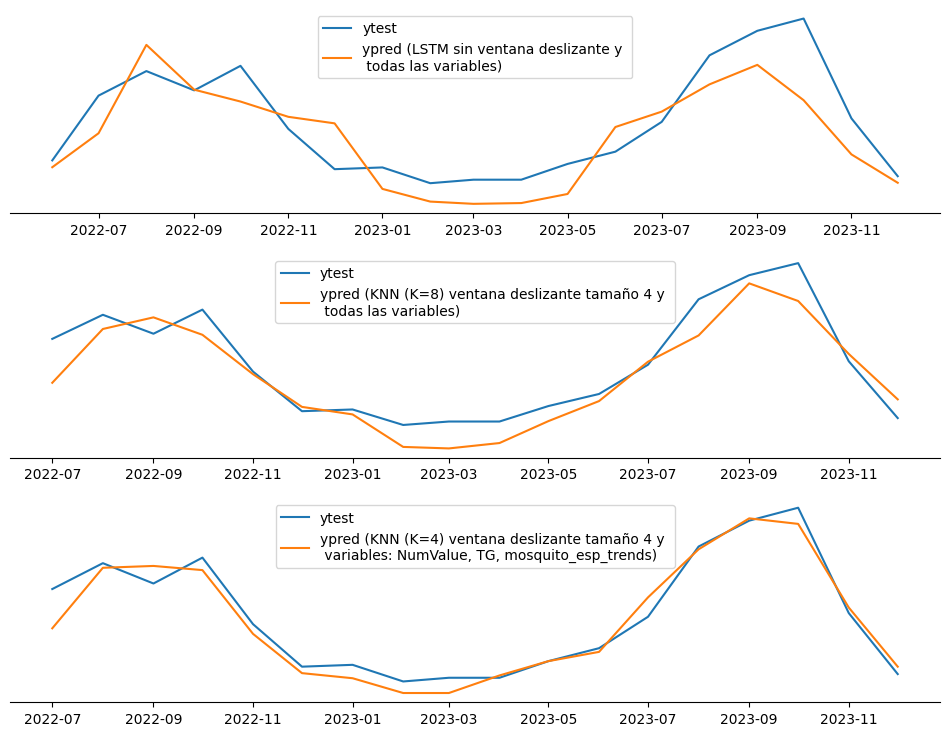

In [35]:
fig,ax=plt.subplots(3,1,figsize=(12,9))
sns.lineplot(data=Y_lstm6,x=Y_lstm6.index,y=Y_lstm6.ytest,label='ytest',ax=ax[0])
sns.lineplot(data=Y_lstm6,x=Y_lstm6.index,y=Y_lstm6.ypred_T,label='ypred (LSTM sin ventana deslizante y \n todas las variables)',ax=ax[0])
sns.lineplot(data=Y_knn2,x=Y_knn2.index,y=Y_knn2.ytest,label='ytest',ax=ax[1])
sns.lineplot(data=Y_knn2,x=Y_knn2.index,y=Y_knn2.ypred,label='ypred (KNN (K=8) ventana deslizante tamaño 4 y \n todas las variables)',ax=ax[1])
sns.lineplot(data=Y_knn3,x=Y_knn3.index,y=Y_knn3.ytest,label='ytest',ax=ax[2])
sns.lineplot(data=Y_knn3,x=Y_knn3.index,y=Y_knn3.ypred,label='ypred (KNN (K=4) ventana deslizante tamaño 4 y \n variables: NumValue, TG, mosquito_esp_trends)',ax=ax[2])

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].yaxis.set_ticks([])
ax[0].set(ylabel=None)
ax[0].set_xlabel("")

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].yaxis.set_ticks([])
ax[1].set(ylabel=None)
ax[1].set_xlabel("")

ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].yaxis.set_ticks([])
ax[2].set(ylabel=None)
ax[2].set_xlabel("")

plt.legend()
#plt.xticks(rotation=90)
plt.show()